In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from fantasy_football.constants import PROJECT_ROOT
from fantasy_football.modelling.folds import TrainTestSplitStrategy
from fantasy_football.modelling.minutes import MinutesPredictor, MINUTES_SPEC
from fantasy_football.storage.database import get_connection    
from fantasy_football.storage.tables import MINUTES_PREDICTION, TM_PLAYER, TM_PLAYER_SEASON, TM_MARKET_VALUE, TM_TRANSFER

/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Checklist

- ~~Go through Null values to inspect that they make sense~~
- ~~Check distributions of all data~~
- ~~Create a train/test split~~
- [ ] Create feature for price rank position transfermarkt
- [ ] Create feature for number of players same position transfermarkt
- [ ] Create feature for price drop/increase/flat
- [ ] Create feature for count new transfers same position?

In [2]:
connection = get_connection()

In [3]:
minutes_predictor = MinutesPredictor(
    experiment_name="minutes_played_classification",
    params={},
    model_spec=MINUTES_SPEC,
    connection=connection,
    fold_strategy=TrainTestSplitStrategy(),
)

In [4]:
training_data = minutes_predictor.build_training_data()
training_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0


In [5]:
sql = """
WITH transfers AS (
SELECT 
     tm_player_id 
    ,joined_club
    ,transfer_date_parsed AS date_joined
    ,LEAD(transfer_date_parsed) OVER (PARTITION BY tm_player_id ORDER BY transfer_date_parsed ASC) AS date_left

FROM tm_transfer
),

market_values AS (
SELECT 
     tm_player_id
    ,value_eur
    ,value_date AS date_value_started
    ,LEAD(value_date) OVER (PARTITION BY tm_player_id ORDER BY value_date ASC) AS date_value_ended

FROM tm_market_value

UNION ALL

-- head interval, so time before a player's first valuation still joins
SELECT
     tm_player_id
    ,CAST(NULL AS BIGINT) AS value_eur
    ,CAST(NULL AS DATE) AS date_value_started
    ,MIN(value_date) AS date_value_ended

FROM tm_market_value
GROUP BY tm_player_id
)
SELECT
     tm.tm_player_id
    ,tm.name
    ,tm.position AS tm_position
    ,tf.joined_club
    ,tf.date_joined
    ,tf.date_left
    ,mv.value_eur AS value
    ,mv.date_value_started
    ,mv.date_value_ended
    ,ps.element AS fpl_element
    ,ps.season
    ,pm.gw
    ,pm.opponent
    ,pm.kickoff_time
    
FROM tm_player tm

LEFT JOIN transfers tf ON tm.tm_player_id = tf.tm_player_id
LEFT JOIN market_values mv ON tm.tm_player_id = mv.tm_player_id
    AND COALESCE(mv.date_value_started, CAST('-infinity' AS DATE)) < COALESCE(tf.date_left, CAST('infinity' AS DATE))
    AND COALESCE(mv.date_value_ended, CAST('infinity' AS DATE)) > COALESCE(tf.date_joined, CAST('-infinity' AS DATE))
LEFT JOIN tm_player_map mp ON tm.tm_player_id = mp.tm_player_id
LEFT JOIN player_season ps ON mp.player_code = ps.player_code
INNER JOIN player_match pm ON ps.element = pm.element 
    AND ps.season = pm.season
    AND pm.kickoff_time >= COALESCE(GREATEST(tf.date_joined, mv.date_value_started), CAST('-infinity' AS DATE))
    AND pm.kickoff_time < COALESCE(LEAST(tf.date_left, mv.date_value_ended), CAST('infinity' AS DATE))
LEFT JOIN player_week pw ON ps.element = pw.element
    AND ps.season = pw.season
    AND pw.gw = pm.gw

ORDER BY tm.tm_player_id, tf.date_joined, mv.date_value_started NULLS FIRST, pm.kickoff_time
"""

In [6]:
transfermarkt_data = connection.sql(sql).pl()

In [7]:
all_data = training_data.join(transfermarkt_data, left_on=["element", "season", "gw", "opponent"], right_on=["fpl_element", "season", "gw", "opponent"], how="left")
all_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_right,date_value_started,date_value_ended,kickoff_time
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs]
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0,"""35664""","""Mesut Özil""","""Attacking Midfield""","""Arsenal""",2013-09-02,2021-01-25,12000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0,"""34322""","""Sokratis Papastathopoulos""","""Centre-Back""","""Arsenal""",2018-07-02,2021-01-25,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0,"""46741""","""David Luiz""","""Centre-Back""","""Arsenal""",2019-08-09,2021-09-01,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0,"""58864""","""Pierre-Emerick Aubameyang""","""Centre-Forward""","""Arsenal""",2018-01-31,2022-01-31,56000000,2020-04-08,2020-10-13,2020-09-12 11:30:00
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0,"""112988""","""Cédric Soares""","""Right-Back""","""Arsenal""",2020-07-01,2023-01-31,8000000,2020-04-08,2020-10-13,2020-09-12 11:30:00


In [8]:
# will just drop null transfermarkt rows
all_data = all_data.filter(pl.col("tm_player_id").is_not_null())
all_data =all_data.rename({"value_right": "value_tm"})

In [9]:
# Share of minutes by position
tm_position_mapping = {
    "Attacking Midfield": "AM",
    "Centre-Back": "CB",
    "Centre-Forward": "ST",
    "Right-Back": "RB",
    "Goalkeeper": "GK",
    "Defensive Midfield": "CM",
    "Central Midfield": "CM",
    "Left-Back": "LB",
    "Left Midfield": "LM",
    "Left Winger": "LM",
    "Right Midfield": "RM",
    "Right Winger": "RM",
    "Second Striker": "AM"
}

all_data = all_data.with_columns(pl.col("tm_position").replace_strict(tm_position_mapping).alias("tm_position_mapped"))

all_data.head()

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str
"""2020-21""",1,1,8,0,"""0_minutes""",70,0.039437,4,14,100,13,3,0.0,0,2161,0.631579,4.583333,2,2,null,"""MID""",0,0,"""35664""","""Mesut Özil""","""Attacking Midfield""","""Arsenal""",2013-09-02,2021-01-25,12000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""AM"""
"""2020-21""",1,2,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,null,0,null,null,null,0,null,null,"""DEF""",1,0,"""34322""","""Sokratis Papastathopoulos""","""Centre-Back""","""Arsenal""",2018-07-02,2021-01-25,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""CB"""
"""2020-21""",1,3,8,0,"""0_minutes""",55,0.030986,1,13,100,12,0,0.0,0,838,0.236842,3.444444,2,2,null,"""DEF""",0,0,"""46741""","""David Luiz""","""Centre-Back""","""Arsenal""",2019-08-09,2021-09-01,8000000,2020-07-30,2020-10-13,2020-09-12 11:30:00,"""CB"""
"""2020-21""",1,4,8,90,"""60_minutes_plus""",120,0.067606,1,14,100,13,0,71.2,0,1056,0.923077,6.916667,1,2,null,"""MID""",0,0,"""58864""","""Pierre-Emerick Aubameyang""","""Centre-Forward""","""Arsenal""",2018-01-31,2022-01-31,56000000,2020-04-08,2020-10-13,2020-09-12 11:30:00,"""ST"""
"""2020-21""",1,5,8,0,"""0_minutes""",50,0.028169,3,13,100,12,2,90.0,0,2794,0.815789,2.709677,2,2,null,"""DEF""",0,0,"""112988""","""Cédric Soares""","""Right-Back""","""Arsenal""",2020-07-01,2023-01-31,8000000,2020-04-08,2020-10-13,2020-09-12 11:30:00,"""RB"""


In [10]:
# Register the position mapping as a view so the query isn't carrying it
tm_position_group = pl.DataFrame(
    {
        "tm_position": list(tm_position_mapping),
        "position_group": list(tm_position_mapping.values()),
    }
)
connection.register("tm_position_group", tm_position_group)

position_share_sql = """
WITH player_position AS (
SELECT
     ps.season
    ,ps.element
    ,ps.player_code
    ,pm.position_group

FROM player_season AS ps
JOIN tm_player_map AS m ON m.player_code = ps.player_code
JOIN tm_player AS tp ON tp.tm_player_id = m.tm_player_id
JOIN tm_position_group AS pm ON pm.tm_position = tp.position
),

season_minutes AS (
SELECT
     w.season
    ,w.element
    ,pp.player_code
    ,pp.position_group
    ,w.team
    ,SUM(w.minutes) AS minutes
    ,COUNT(*) FILTER (WHERE w.minutes > 0) AS games_played

FROM player_week AS w
JOIN player_position AS pp
    ON pp.season = w.season
    AND pp.element = w.element
GROUP BY ALL
),

position_share AS (
SELECT
     *
    ,SUM(minutes) OVER (PARTITION BY season, team, position_group) AS team_position_minutes
    ,minutes / NULLIF(SUM(minutes) OVER (PARTITION BY season, team, position_group), 0) AS pct_position_minutes

FROM season_minutes
),

-- Calendar previous season, not LAG over the seasons present: player_week
-- jumps 2017-18 -> 2020-21, so LAG would call 2017-18 the prior season.
seasons AS (
SELECT
     season
    ,printf('%d-%02d', CAST(LEFT(season, 4) AS INT) - 1, CAST(LEFT(season, 4) AS INT) % 100) AS prev_season

FROM (SELECT DISTINCT season FROM position_share)
)

SELECT
     c.season
    ,c.element
    ,c.player_code
    ,c.team
    ,c.position_group
    ,c.minutes
    ,c.games_played
    ,c.team_position_minutes
    ,c.pct_position_minutes
    ,p.minutes AS prev_minutes
    ,p.games_played AS prev_games_played
    ,p.pct_position_minutes AS prev_pct_position_minutes

FROM position_share AS c
JOIN seasons AS s ON s.season = c.season
LEFT JOIN position_share AS p
    ON p.season = s.prev_season
    AND p.player_code = c.player_code
    AND p.team = c.team
ORDER BY c.season DESC, c.pct_position_minutes DESC
"""

position_share = connection.sql(position_share_sql).pl()

position_share.head()


season,element,player_code,team,position_group,minutes,games_played,team_position_minutes,pct_position_minutes,prev_minutes,prev_games_played,prev_pct_position_minutes
str,i64,i64,str,str,"decimal[38,0]",i64,"decimal[38,0]",f64,"decimal[38,0]",i64,f64
"""2026-27""",412,465247,"""Man Utd""","""GK""",270,3,270,1.0,2880,32,0.842105
"""2026-27""",96,440089,"""Brentford""","""AM""",169,3,169,1.0,2046,33,0.933394
"""2026-27""",467,85633,"""Nott'm Forest""","""GK""",270,3,270,1.0,2667,31,0.780053
"""2026-27""",175,451284,"""Coventry City""","""RB""",270,3,270,1.0,null,null,null
"""2026-27""",214,209400,"""Crystal Palace""","""AM""",269,3,269,1.0,1899,27,0.686303


In [11]:
lookback_days = 365

arrivals_sql = """
WITH spells AS (
SELECT
     t.tm_player_id
    ,t.joined_club
    ,t.transfer_date_parsed AS date_joined
    ,LEAD(t.transfer_date_parsed) OVER (PARTITION BY t.tm_player_id ORDER BY t.transfer_date_parsed ASC) AS date_left
    ,g.position_group

FROM tm_transfer AS t
JOIN tm_player AS p ON p.tm_player_id = t.tm_player_id
JOIN tm_position_group AS g ON g.tm_position = p.position
WHERE t.transfer_date_parsed IS NOT NULL
),

market_values AS (
SELECT
     tm_player_id
    ,value_eur
    ,value_date AS date_value_started
    ,LEAD(value_date) OVER (PARTITION BY tm_player_id ORDER BY value_date ASC) AS date_value_ended

FROM tm_market_value
),

fixtures AS (
SELECT
     pm.season
    ,pm.gw
    ,pm.element
    ,pm.opponent
    ,pm.kickoff_time
    ,s.tm_player_id
    ,s.joined_club
    ,s.position_group
    ,s.date_joined
    ,mv.value_eur AS player_value_eur

FROM player_match AS pm
JOIN player_season AS ps ON ps.season = pm.season AND ps.element = pm.element
JOIN tm_player_map AS mp ON mp.player_code = ps.player_code
JOIN spells AS s
    ON s.tm_player_id = mp.tm_player_id
    AND pm.kickoff_time >= s.date_joined
    AND pm.kickoff_time < COALESCE(s.date_left, CAST('infinity' AS DATE))
LEFT JOIN market_values AS mv
    ON mv.tm_player_id = s.tm_player_id
    AND pm.kickoff_time >= mv.date_value_started
    AND pm.kickoff_time < COALESCE(mv.date_value_ended, CAST('infinity' AS DATE))
),

arrivals AS (
SELECT
     f.season
    ,f.gw
    ,f.element
    ,f.opponent
    ,a.tm_player_id AS rival_tm_player_id
    ,a.date_joined AS rival_date_joined
    ,f.player_value_eur
    ,rv.value_eur AS rival_value_eur
    ,rv.value_eur / f.player_value_eur AS rival_value_share

FROM fixtures AS f
JOIN spells AS a
    ON a.joined_club = f.joined_club
    AND a.position_group = f.position_group
    AND a.tm_player_id <> f.tm_player_id
    AND a.date_joined <= f.kickoff_time
    AND a.date_joined > f.kickoff_time - INTERVAL {lookback_days} DAY
LEFT JOIN market_values AS rv
    ON rv.tm_player_id = a.tm_player_id
    AND f.kickoff_time >= rv.date_value_started
    AND f.kickoff_time < COALESCE(rv.date_value_ended, CAST('infinity' AS DATE))
)

SELECT
     f.season
    ,f.gw
    ,f.element
    ,f.opponent
    ,f.position_group
    ,f.player_value_eur
    ,COUNT(a.rival_tm_player_id) AS rivals_joined_same_pos
    ,COUNT(a.rival_tm_player_id) > 0 AS rival_joined_same_pos
    ,COUNT(*) FILTER (WHERE a.rival_value_eur > f.player_value_eur) AS higher_value_rivals_joined_same_pos
    ,COUNT(*) FILTER (WHERE a.rival_value_eur > f.player_value_eur) > 0 AS higher_value_rival_joined_same_pos
    ,MAX(a.rival_value_eur) AS max_rival_value_eur
    ,MAX(a.rival_value_share) AS max_rival_value_share
    ,MIN(date_diff('day', a.rival_date_joined, CAST(f.kickoff_time AS DATE))) AS days_since_rival_joined

FROM fixtures AS f
LEFT JOIN arrivals AS a
    ON a.season = f.season
    AND a.gw = f.gw
    AND a.element = f.element
    AND a.opponent = f.opponent
GROUP BY ALL
ORDER BY f.season DESC, f.gw, f.element
"""

position_arrivals = connection.sql(arrivals_sql.format(lookback_days=lookback_days)).pl()


In [12]:
# Join the new transfermarkt features onto all_data
#
# position_share is season grain and one row per club, so a mid-season transfer
# gives two rows per player. all_data has no team column, so collapse to the
# club the player played most minutes for that season before joining.
position_share_by_player = (
    position_share
    .sort("minutes", descending=True)
    .unique(subset=["season", "element"], keep="first")
    .select(
        "season",
        "element",
        "position_group",
        "games_played",
        "pct_position_minutes",
        "prev_pct_position_minutes",
    )
)

rows_before = all_data.height

all_data = all_data.join(
    position_share_by_player,
    on=["season", "element"],
    how="left",
).join(
    position_arrivals.drop("position_group", "player_value_eur"),
    on=["season", "gw", "element", "opponent"],
    how="left",
)

assert all_data.height == rows_before, "join fanned out"

NEW_FEATURES = [
    "games_played",
    "pct_position_minutes",
    "prev_pct_position_minutes",
    "rivals_joined_same_pos",
    "rival_joined_same_pos",
    "higher_value_rivals_joined_same_pos",
    "higher_value_rival_joined_same_pos",
    "max_rival_value_eur",
    "days_since_rival_joined",
]

print(all_data.select(NEW_FEATURES).null_count())
all_data.select(["season", "gw", "element", "tm_position"] + NEW_FEATURES).head()


shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ games_pla ┆ pct_posit ┆ prev_pct_ ┆ rivals_jo ┆ … ┆ higher_va ┆ higher_va ┆ max_rival ┆ days_sin │
│ yed       ┆ ion_minut ┆ position_ ┆ ined_same ┆   ┆ lue_rival ┆ lue_rival ┆ _value_eu ┆ ce_rival │
│ ---       ┆ es        ┆ minutes   ┆ _pos      ┆   ┆ s_joined_ ┆ _joined_s ┆ r         ┆ _joined  │
│ u32       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ sam…      ┆ ame…      ┆ ---       ┆ ---      │
│           ┆ u32       ┆ u32       ┆ u32       ┆   ┆ ---       ┆ ---       ┆ u32       ┆ u32      │
│           ┆           ┆           ┆           ┆   ┆ u32       ┆ u32       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 470       ┆ 79113     ┆ 53        ┆ … ┆ 53        ┆ 53        ┆ 44547     ┆ 41804    │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴

season,gw,element,tm_position,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,days_since_rival_joined
str,i64,i64,str,i64,f64,f64,i64,bool,i64,bool,i64,i64
"""2020-21""",1,1,"""Attacking Midfield""",0,0.0,null,1,true,0,false,2700000,42
"""2020-21""",1,2,"""Centre-Back""",0,0.0,null,5,true,2,true,22500000,11
"""2020-21""",1,3,"""Centre-Back""",20,0.180478,null,5,true,2,true,22500000,11
"""2020-21""",1,4,"""Centre-Forward""",29,0.500322,null,1,true,0,false,15000000,254
"""2020-21""",1,5,"""Right-Back""",10,0.224231,null,0,false,0,false,null,null


In [13]:
# Value rank within the club's mapped TM position group
#
# Mirrors add_positional_value_rank, but partitions on tm_position_mapped
# instead of the FPL position and ranks on the transfermarkt value.
# all_data has no team column, so pull the per-gameweek club from player_week.
player_team = connection.sql("""
SELECT
     season
    ,gw
    ,element
    ,team

FROM player_week
""").pl()

all_data = all_data.join(player_team, on=["season", "gw", "element"], how="left")

# Ranked in duckdb rather than with polars .over(): the equivalent polars
# window expressions returned NaN on ~2k rows whose inputs were all present.
# all_data is match grain, so a double gameweek carries two rows per player.
# Rank on one row per player-gameweek or the group counts double.
rank_input = all_data.select(
    "season", "gw", "element", "team", "tm_position_mapped", "value_tm"
).unique(subset=["season", "gw", "element"])
connection.register("rank_input", rank_input)

tm_value_rank = connection.sql("""
WITH ranked AS (
SELECT
     season
    ,gw
    ,element
    -- No transfermarkt value is not the same as being the cheapest, so those
    -- players are counted in the group but not ranked within it.
    ,CASE
        WHEN value_tm IS NULL THEN NULL
        ELSE RANK() OVER (PARTITION BY season, gw, team, tm_position_mapped ORDER BY value_tm DESC)
     END AS tm_pos_value_rank
    ,COUNT(*) OVER (PARTITION BY season, gw, team, tm_position_mapped) AS players_same_tm_pos
    ,value_tm / NULLIF(SUM(value_tm) OVER (PARTITION BY season, gw, team, tm_position_mapped), 0) AS tm_pos_value_share

FROM rank_input
)

SELECT
     season
    ,gw
    ,element
    ,tm_pos_value_rank
    ,players_same_tm_pos
    ,tm_pos_value_share
    -- Rank is not comparable across group sizes: 3rd of 3 and 3rd of 8 differ.
    -- A player alone in their position group is top of it, so 0.
    ,CASE
        WHEN tm_pos_value_rank IS NULL THEN NULL
        WHEN players_same_tm_pos > 1
        THEN (tm_pos_value_rank - 1.0) / (players_same_tm_pos - 1.0)
        ELSE 0.0
     END AS tm_pos_value_rank_norm

FROM ranked
""").pl()

rows_before = all_data.height
all_data = all_data.join(tm_value_rank, on=["season", "gw", "element"], how="left")
assert all_data.height == rows_before, "rank join fanned out"

TM_RANK_FEATURES = [
    "tm_pos_value_rank",
    "players_same_tm_pos",
    "tm_pos_value_share",
    "tm_pos_value_rank_norm",
]

for feature in TM_RANK_FEATURES:
    column = all_data[feature]
    nan_count = column.is_nan().sum() if column.dtype.is_float() else 0
    print(f"{feature}: {column.null_count()} null, {nan_count} nan")

all_data.select(["season", "gw", "element", "team", "tm_position_mapped", "value_tm"] + TM_RANK_FEATURES).head()


tm_pos_value_rank: 7570 null, 0 nan
players_same_tm_pos: 0 null, 0 nan
tm_pos_value_share: 7570 null, 0 nan
tm_pos_value_rank_norm: 7570 null, 0 nan


season,gw,element,team,tm_position_mapped,value_tm,tm_pos_value_rank,players_same_tm_pos,tm_pos_value_share,tm_pos_value_rank_norm
str,i64,i64,str,str,i64,i64,i64,f64,f64
"""2020-21""",1,1,"""Arsenal""","""AM""",12000000,1,2,0.816327,0.0
"""2020-21""",1,2,"""Arsenal""","""CB""",8000000,7,9,0.067625,0.75
"""2020-21""",1,3,"""Arsenal""","""CB""",8000000,7,9,0.067625,0.75
"""2020-21""",1,4,"""Arsenal""","""ST""",56000000,1,3,0.470588,0.0
"""2020-21""",1,5,"""Arsenal""","""RB""",8000000,3,3,0.146789,1.0


In [14]:
# Minutes in the previous game, and the one before that
#
# Keyed on player_code rather than element: FPL reassigns element ids each
# season, so an element-keyed window merges different people. Ordered by
# kickoff so the window is continuous across seasons, and LAG only ever
# looks backwards, so a row never sees its own minutes.
prev_minutes = connection.sql("""
WITH player_games AS (
SELECT
     pm.season
    ,pm.gw
    ,pm.element
    ,pm.opponent
    ,pm.kickoff_time
    ,pm.minutes
    ,ps.player_code

FROM player_match AS pm
JOIN player_season AS ps
    ON ps.season = pm.season
    AND ps.element = pm.element
WHERE ps.player_code IS NOT NULL
)

SELECT
     season
    ,gw
    ,element
    ,opponent
    ,LAG(minutes, 1) OVER w AS prev_game_minutes
    ,LAG(minutes, 2) OVER w AS prev_game_minutes_2
    -- The player_week gap (no 2018-19 or 2019-20) means a "previous game"
    -- can be years old. This is how to spot those rows.
    ,date_diff('day', LAG(CAST(kickoff_time AS DATE), 1) OVER w, CAST(kickoff_time AS DATE)) AS days_since_prev_game

FROM player_games
WINDOW w AS (PARTITION BY player_code ORDER BY kickoff_time)
""").pl()

rows_before = all_data.height
all_data = all_data.join(prev_minutes, on=["season", "gw", "element", "opponent"], how="left")
assert all_data.height == rows_before, "prev minutes join fanned out"

PREV_MINUTES_FEATURES = ["prev_game_minutes", "prev_game_minutes_2", "days_since_prev_game"]

print(all_data.select(PREV_MINUTES_FEATURES).null_count())
print(all_data.group_by(pl.col("prev_game_minutes").is_null()).agg(pl.col("minutes").mean(), pl.len()))

all_data.select(["season", "gw", "element", "minutes"] + PREV_MINUTES_FEATURES).head()


shape: (1, 3)
┌───────────────────┬─────────────────────┬──────────────────────┐
│ prev_game_minutes ┆ prev_game_minutes_2 ┆ days_since_prev_game │
│ ---               ┆ ---                 ┆ ---                  │
│ u32               ┆ u32                 ┆ u32                  │
╞═══════════════════╪═════════════════════╪══════════════════════╡
│ 1663              ┆ 3320                ┆ 1663                 │
└───────────────────┴─────────────────────┴──────────────────────┘
shape: (2, 3)
┌───────────────────┬───────────┬────────┐
│ prev_game_minutes ┆ minutes   ┆ len    │
│ ---               ┆ ---       ┆ ---    │
│ bool              ┆ f64       ┆ u32    │
╞═══════════════════╪═══════════╪════════╡
│ false             ┆ 28.089032 ┆ 160796 │
│ true              ┆ 18.538785 ┆ 1663   │
└───────────────────┴───────────┴────────┘


season,gw,element,minutes,prev_game_minutes,prev_game_minutes_2,days_since_prev_game
str,i64,i64,i64,i64,i64,i64
"""2020-21""",1,1,0,0,0,853
"""2020-21""",1,2,0,null,null,null
"""2020-21""",1,3,0,0,0,853
"""2020-21""",1,4,90,66,90,853
"""2020-21""",1,5,0,90,90,853


In [15]:
# As-of versions of the season-share features
#
# pct_position_minutes is a full-season total, so a GW10 row carries minutes
# from gameweeks that have not happened. These accumulate strictly before the
# current gameweek instead, so they are known at prediction time.
position_share_to_date = connection.sql("""
WITH player_position AS (
SELECT
     ps.season
    ,ps.element
    ,pm.position_group

FROM player_season AS ps
JOIN tm_player_map AS m ON m.player_code = ps.player_code
JOIN tm_player AS tp ON tp.tm_player_id = m.tm_player_id
JOIN tm_position_group AS pm ON pm.tm_position = tp.position
),

player_gw AS (
SELECT
     w.season
    ,w.gw
    ,w.element
    ,w.team
    ,pp.position_group
    ,w.minutes

FROM player_week AS w
JOIN player_position AS pp
    ON pp.season = w.season
    AND pp.element = w.element
),

-- Minutes each club gave to a position group in each gameweek, so the
-- denominator can accumulate the same way the numerator does.
team_position_gw AS (
SELECT
     season
    ,gw
    ,team
    ,position_group
    ,SUM(minutes) AS team_position_minutes

FROM player_gw
GROUP BY ALL
),

running AS (
SELECT
     p.season
    ,p.gw
    ,p.element
    ,p.team
    ,p.position_group
    -- Strictly before this gameweek: the row never sees its own minutes.
    ,COALESCE(SUM(p.minutes) OVER (
        PARTITION BY p.season, p.element
        ORDER BY p.gw
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING), 0) AS minutes_to_date
    ,COALESCE(SUM(t.team_position_minutes) OVER (
        PARTITION BY p.season, p.team, p.position_group
        ORDER BY p.gw
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING), 0) AS team_position_minutes_to_date
    ,COALESCE(SUM(CASE WHEN p.minutes > 0 THEN 1 ELSE 0 END) OVER (
        PARTITION BY p.season, p.element
        ORDER BY p.gw
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING), 0) AS games_played_to_date

FROM player_gw AS p
JOIN team_position_gw AS t
    ON t.season = p.season
    AND t.gw = p.gw
    AND t.team = p.team
    AND t.position_group = p.position_group
)

SELECT
     season
    ,gw
    ,element
    -- Cast off duckdb's DECIMAL sums: sklearn cannot read Decimal objects.
    ,CAST(games_played_to_date AS BIGINT) AS games_played_to_date
    ,CAST(minutes_to_date AS BIGINT) AS minutes_to_date
    ,CAST(team_position_minutes_to_date AS BIGINT) AS team_position_minutes_to_date
    ,CAST(minutes_to_date AS DOUBLE) / NULLIF(team_position_minutes_to_date, 0) AS pct_position_minutes_to_date

FROM running
""").pl()

rows_before = all_data.height
all_data = all_data.join(position_share_to_date, on=["season", "gw", "element"], how="left")
assert all_data.height == rows_before, "as-of join fanned out"

AS_OF_FEATURES = [
    "games_played_to_date",
    "minutes_to_date",
    "pct_position_minutes_to_date",
]

print(all_data.select(AS_OF_FEATURES).null_count())
all_data.select(["season", "gw", "element"] + AS_OF_FEATURES).head()


shape: (1, 3)
┌──────────────────────┬─────────────────┬──────────────────────────────┐
│ games_played_to_date ┆ minutes_to_date ┆ pct_position_minutes_to_date │
│ ---                  ┆ ---             ┆ ---                          │
│ u32                  ┆ u32             ┆ u32                          │
╞══════════════════════╪═════════════════╪══════════════════════════════╡
│ 0                    ┆ 0               ┆ 2463                         │
└──────────────────────┴─────────────────┴──────────────────────────────┘


season,gw,element,games_played_to_date,minutes_to_date,pct_position_minutes_to_date
str,i64,i64,i64,i64,f64
"""2020-21""",1,1,0,0,null
"""2020-21""",1,2,0,0,0.0
"""2020-21""",1,3,0,0,0.0
"""2020-21""",1,4,0,0,null
"""2020-21""",1,5,0,0,null


In [16]:
TRAINING_SEASONS = ["2020-21", "2021-22", "2022-23", "2023-24","2024-25"]

training_data = all_data.filter(pl.col("season").is_in(TRAINING_SEASONS))
test_data = all_data.filter(~pl.col("season").is_in(TRAINING_SEASONS))

In [17]:
NUM_FEATURES = [
    "value",
    "value_share_of_team",
    "pos_value_rank",
    "players_same_pos",
    "chance_of_playing_this_round",
    "fit_rivals_same_pos",
    "fit_rivals_ahead",
    "avg_minutes_rolling_5",
    "games_played_this_season",
    "prev_season_minutes",
    "prev_season_start_rate",
    "pl_seasons_played",
    "seasons_since_last_pl",
    "age_years",
    "value_tm",
    "tm_pos_value_rank",
    "players_same_tm_pos",
    "tm_pos_value_share",
    "tm_pos_value_rank_norm",
    "prev_game_minutes",
    "prev_game_minutes_2",
    "days_since_prev_game"
]
CAT_FEATURES = [
    "position",
    "is_pl_newcomer",
    "is_promoted_club",
    "tm_position"
]

# Analysis


In [18]:
all_data.describe()

statistic,season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined,team,tm_pos_value_rank,players_same_tm_pos,tm_pos_value_share,tm_pos_value_rank_norm,prev_game_minutes,prev_game_minutes_2,days_since_prev_game,games_played_to_date,minutes_to_date,team_position_minutes_to_date,pct_position_minutes_to_date
str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""162459""",162459.0,162459.0,162459.0,162459.0,"""162459""",162459.0,162459.0,162459.0,162459.0,162459.0,162459.0,162459.0,160741.0,162459.0,115622.0,115622.0,86578.0,162459.0,115622.0,104595.0,"""162459""",162459.0,162459.0,"""162459""","""162459""","""162459""","""162406""","""162406""","""121795""",154889.0,"""154889""","""158273""","""162459""","""162459""","""162459""",162459.0,161989.0,83346.0,162406.0,162406.0,162406.0,162406.0,117912.0,114401.0,120655.0,"""162459""",154889.0,162459.0,154889.0,154889.0,160796.0,159139.0,160796.0,162459.0,162459.0,162459.0,159996.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1718.0,0.0,46837.0,46837.0,75881.0,0.0,46837.0,57864.0,"""0""",0.0,0.0,"""0""","""0""","""0""","""53""","""53""","""40664""",7570.0,"""7570""","""4186""","""0""","""0""","""0""",0.0,470.0,79113.0,53.0,53.0,53.0,53.0,44547.0,48058.0,41804.0,"""0""",7570.0,0.0,7570.0,7570.0,1663.0,3320.0,1663.0,0.0,0.0,0.0,2463.0
"""mean""",null,20.379622,361.705593,10.502416,27.991272,null,49.723986,0.02807,5.887978,12.133923,79.265692,8.449726,3.891462,28.341328,17.088601,1261.734869,0.362473,3.41938,1.782259,0.356238,25.089572,null,0.2883,0.133074,null,null,null,null,"""2021-10-08 01:10:14.504390""","""2024-05-10 22:57:17.402192""",1.6918e7,"""2023-05-29 22:36:24.650943""","""2023-10-28 11:05:44.571720""","""2023-09-02 23:51:11.394013""",null,null,14.661668,0.245038,0.29884,1.815967,0.742922,0.533841,0.328855,1.5566e7,NaN,142.275098,null,2.869113,5.074997,0.26497,0.454355,28.163779,28.341048,12.129444,7.436399,510.331641,15058.725143,0.084708
"""std""",null,11.049637,213.204839,5.764716,38.727517,null,11.273164,0.007275,4.251863,5.104819,39.83692,3.862751,3.32634,33.73207,10.573799,1101.133185,0.327955,1.335878,1.675021,0.8161,4.442407,null,0.452973,0.339655,null,null,null,null,null,null,2.0086e7,null,null,null,null,null,13.073173,0.290958,0.302621,1.838439,null,0.947147,null,1.6384e7,NaN,90.656532,null,1.859589,2.314991,0.259083,0.372244,38.7924,38.860733,54.949035,8.816864,697.256603,17326.738372,0.17691
"""min""","""2020-21""",1.0,1.0,1.0,0.0,"""0_minutes""",36.0,0.013854,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,15.060917,"""DEF""",0.0,0.0,"""10003""","""Aaron Connolly""","""Attacking Midfield""","""1.FC K'lautern""","""2006-11-17""","""2020-09-16""",0.0,"""2017-06-21""","""2020-10-08""","""2020-09-12 11:30:00""","""AM""","""AM""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Arsenal""",1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
"""25%""",null,11.0,179.0,6.0,0.0,null,44.0,0.023232,2.0,9.0,100.0,6.0,1.0,0.0,8.0,90.0,0.0,2.516129,0.0,0.0,21.691992,null,0.0,0.0,null,null,null,null,"""2020-07-01""","""2023-02-13""",3e6,"""2021-12-23""",""

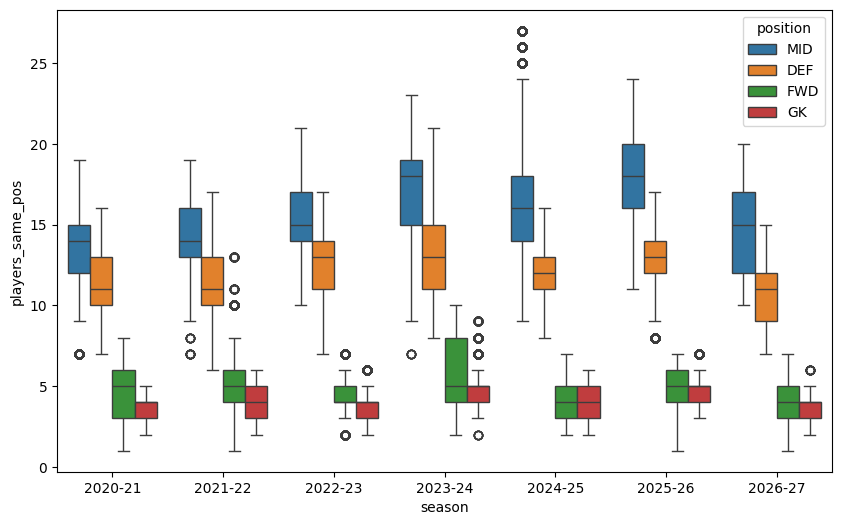

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=all_data,
    x="season",
    y="players_same_pos",
    hue="position",
    ax=ax
)

plt.show()

In [20]:
# Missing prev_season_minutes is always because they are newcomers to the league
# This is the same as prev_season_start_rate
all_data.filter((pl.col("prev_season_minutes").is_null()) & (pl.col("is_pl_newcomer") == False))

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined,team,tm_pos_value_rank,players_same_tm_pos,tm_pos_value_share,tm_pos_value_rank_norm,prev_game_minutes,prev_game_minutes_2,days_since_prev_game,games_played_to_date,minutes_to_date,team_position_minutes_to_date,pct_position_minutes_to_date
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64,str,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64


In [21]:
# This is also the same for the rolling minutes column
all_data.filter((pl.col("avg_minutes_rolling_5").is_null()) & (pl.col("is_pl_newcomer") == False))

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined,team,tm_pos_value_rank,players_same_tm_pos,tm_pos_value_share,tm_pos_value_rank_norm,prev_game_minutes,prev_game_minutes_2,days_since_prev_game,games_played_to_date,minutes_to_date,team_position_minutes_to_date,pct_position_minutes_to_date
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64,str,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64


In [22]:
# missing tm_player_id is where we have player missing in transfermarkt team squad for that season
# fpl has super wide squads compare to transfermarkt. This is always youth players who never play
all_data.filter(pl.col("tm_player_id").is_null())

season,gw,element,opponent,minutes,minutes_bucket,value,value_share_of_team,pos_value_rank,players_same_pos,chance_of_playing_this_round,fit_rivals_same_pos,fit_rivals_ahead,avg_minutes_rolling_5,games_played_this_season,prev_season_minutes,prev_season_start_rate,prev_season_points_per_start,pl_seasons_played,seasons_since_last_pl,age_years,position,is_pl_newcomer,is_promoted_club,tm_player_id,name,tm_position,joined_club,date_joined,date_left,value_tm,date_value_started,date_value_ended,kickoff_time,tm_position_mapped,position_group,games_played,pct_position_minutes,prev_pct_position_minutes,rivals_joined_same_pos,rival_joined_same_pos,higher_value_rivals_joined_same_pos,higher_value_rival_joined_same_pos,max_rival_value_eur,max_rival_value_share,days_since_rival_joined,team,tm_pos_value_rank,players_same_tm_pos,tm_pos_value_share,tm_pos_value_rank_norm,prev_game_minutes,prev_game_minutes_2,days_since_prev_game,games_played_to_date,minutes_to_date,team_position_minutes_to_date,pct_position_minutes_to_date
str,i64,i64,i64,i64,str,i64,f64,i64,i64,i64,i32,i32,f64,i64,i64,f64,f64,i64,i64,f64,str,i8,i8,str,str,str,str,date,date,i64,date,date,datetime[μs],str,str,i64,f64,f64,i64,bool,i64,bool,i64,f64,i64,str,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64


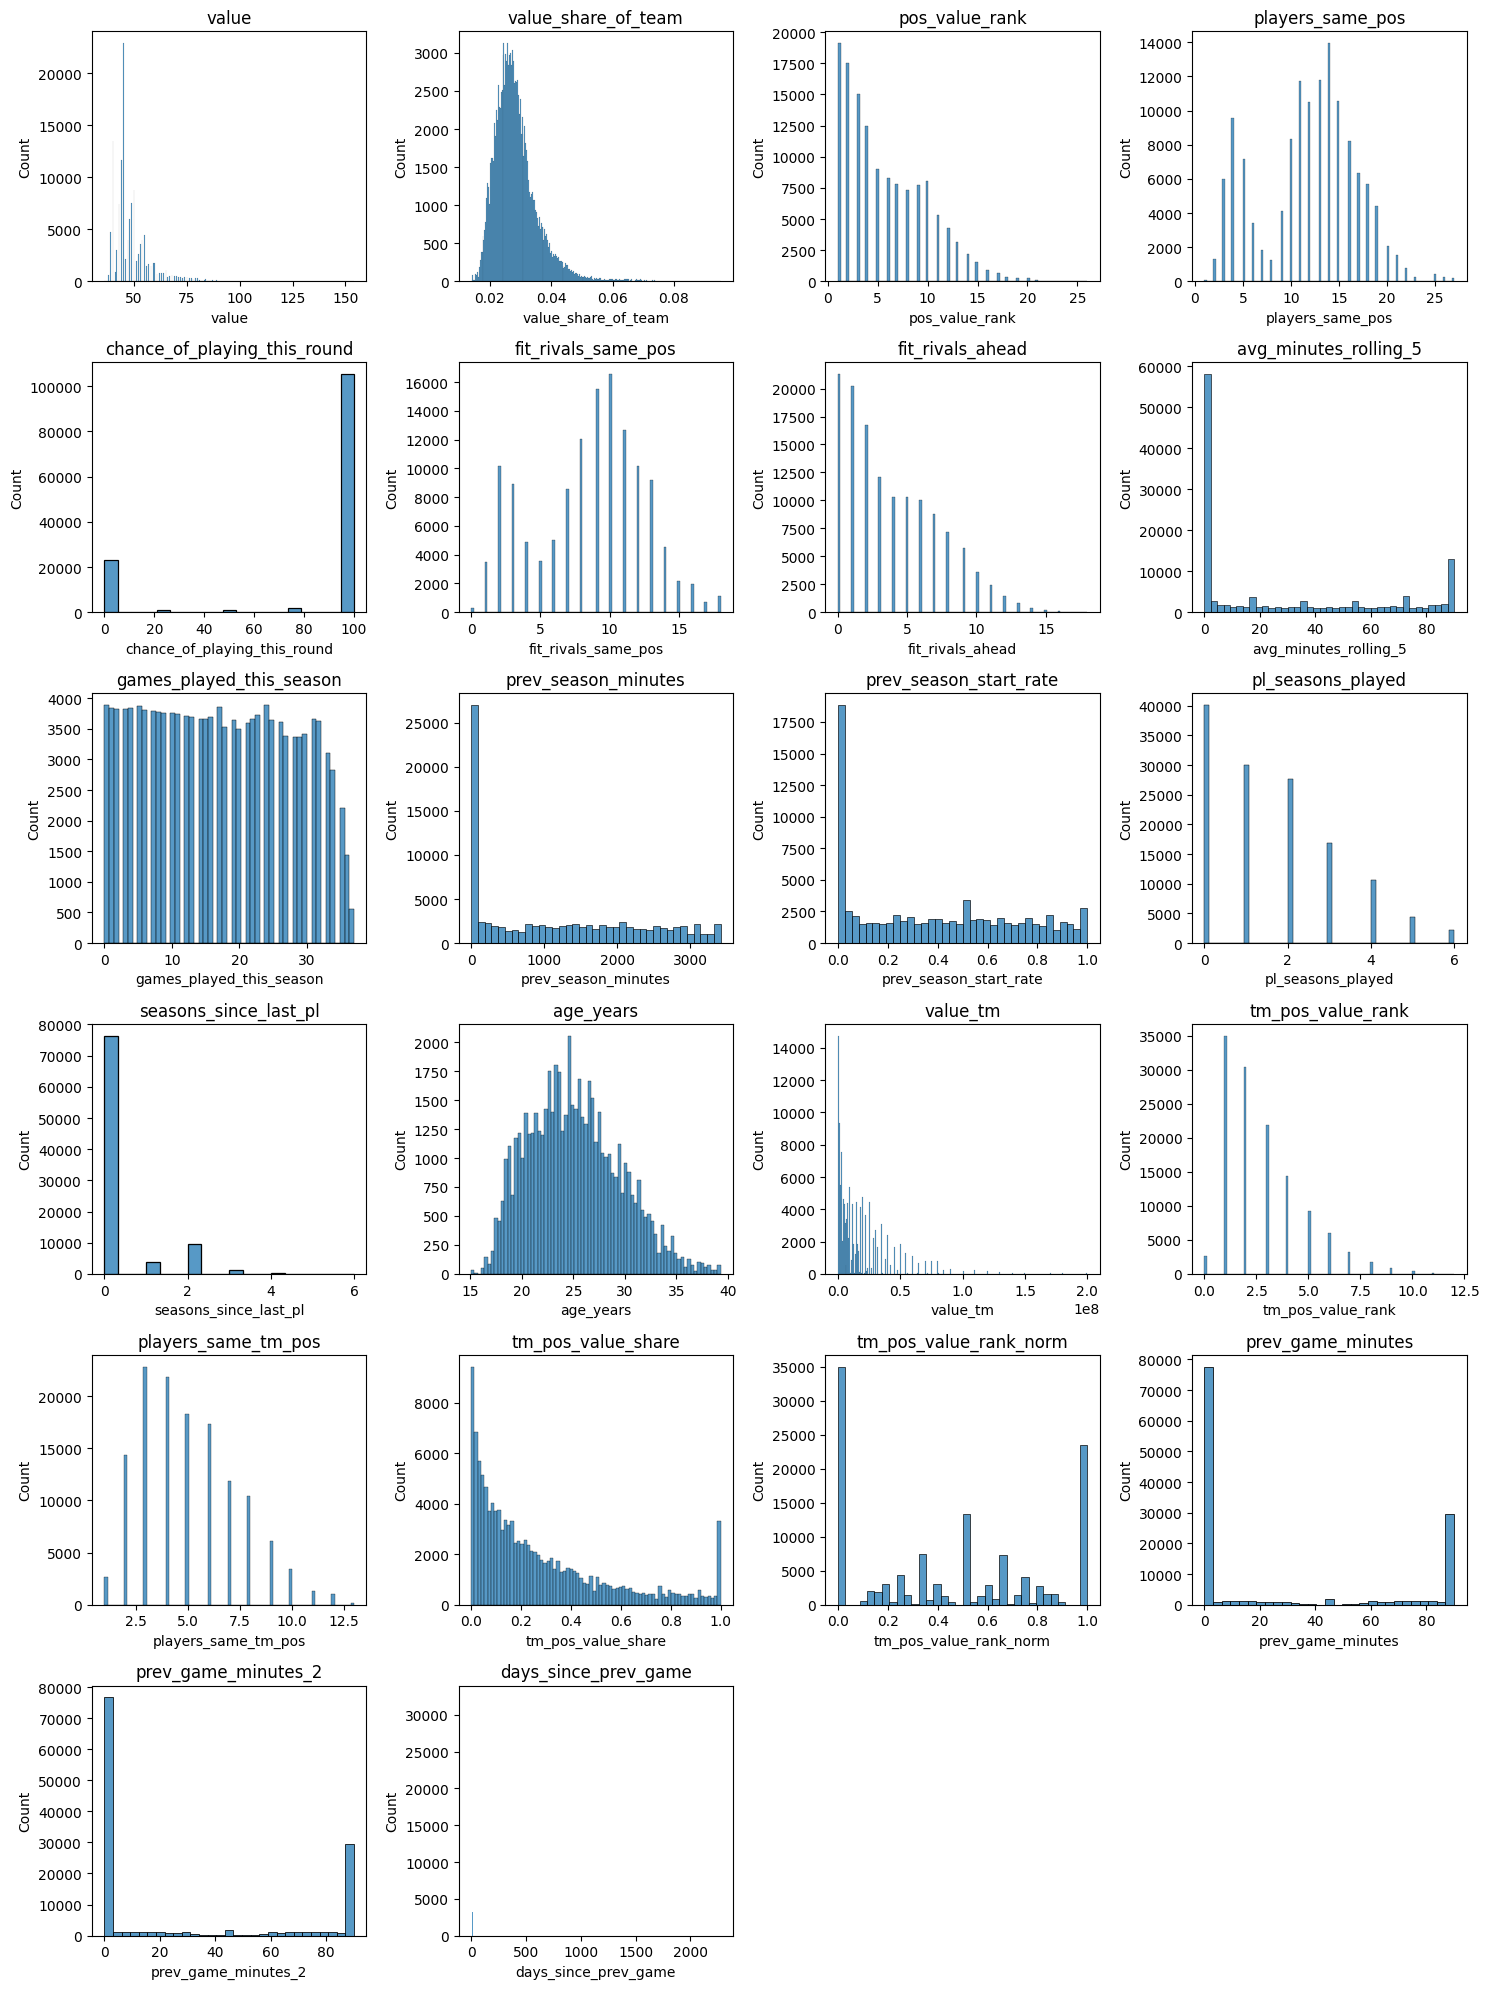

In [23]:
n_cols = 4
n_rows = -(-len(NUM_FEATURES) // n_cols)  # ceiling division

fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, 20))

for i, feature in enumerate(NUM_FEATURES):
    axis = ax[i // n_cols, i % n_cols]
    sns.histplot(data=training_data, x=feature, ax=axis)
    axis.set_title(feature)

for axis in ax.flat[len(NUM_FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()


# How much does value in same position impact minutes? 

What we're trying to answer here, is does the player value (as specified by transfermarkt) compared to other players in the same positions at the same club correlate or influence how many minutes that player gets? And aswell, is there positional variety in the share of minutes (i.e. do some positions tend to get rotated more).

The two hypotheses we have here are:
1. Goalkeepers and defenders are rotated less, midfielders and strikers more often rotated.
2. Players of the highest value in their positions are more likely to get more minutes

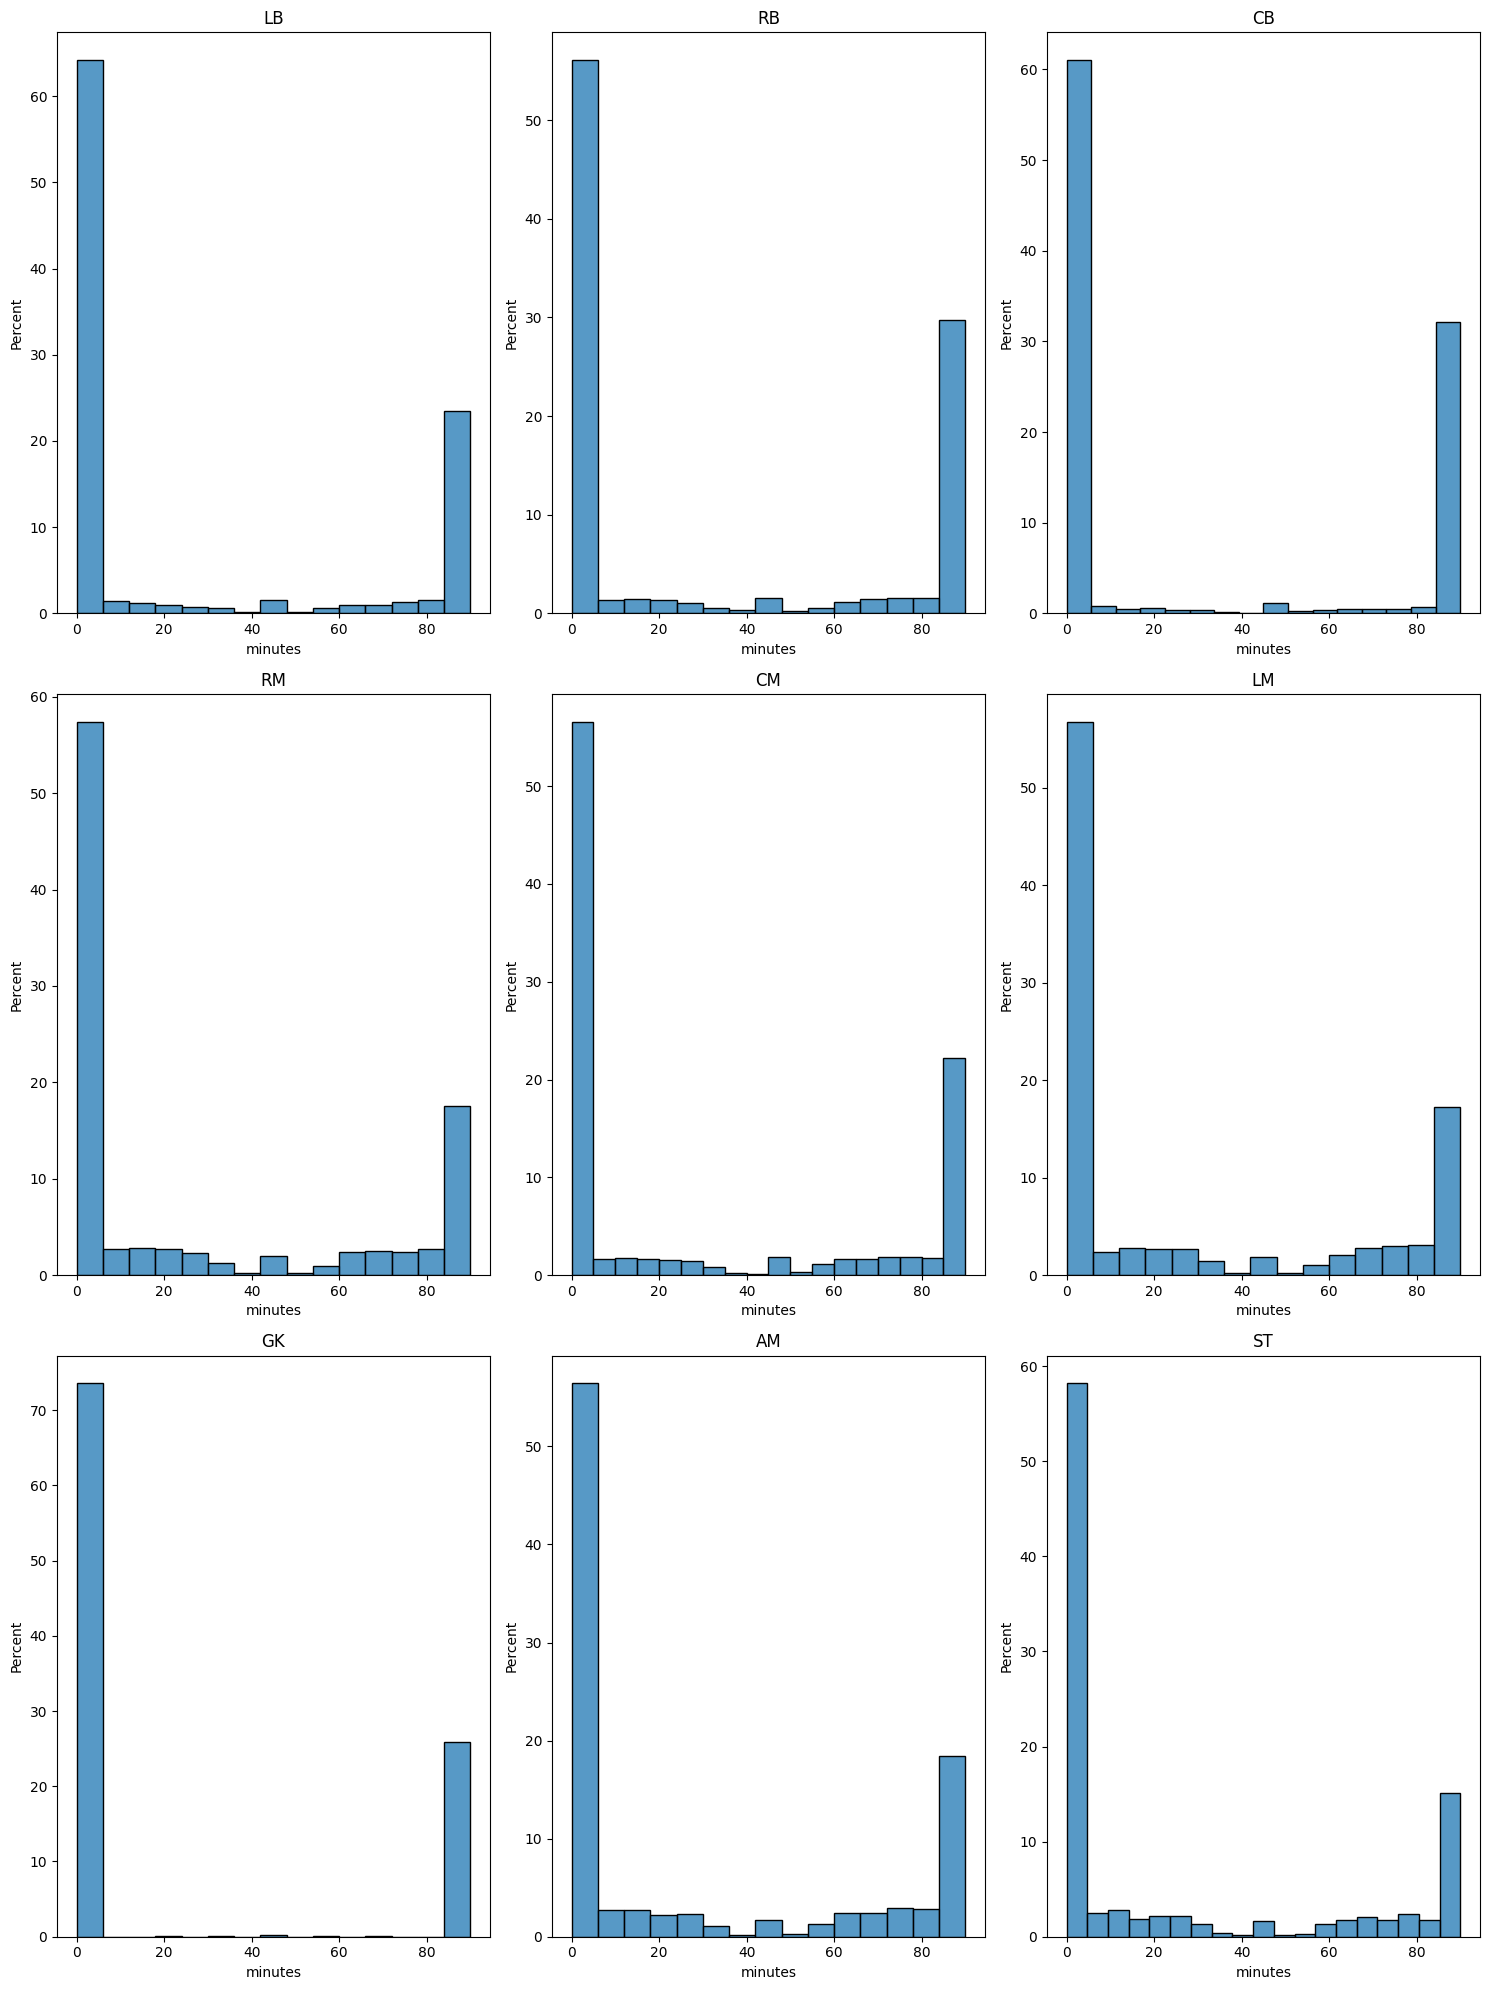

In [24]:
# Keepers and centre backs are subbed off less by the look of it
fig, ax = plt.subplots(3, 3, figsize=(15, 20))

for i, position in enumerate(training_data["tm_position_mapped"].unique().to_list()):
    position_subset = training_data.filter(pl.col("tm_position_mapped") == position)
    sns.histplot(data=position_subset, x="minutes", ax=ax[i // 3, i % 3], stat="percent")
    ax[i // 3, i % 3].set_title(position)

plt.tight_layout()
plt.show()
    

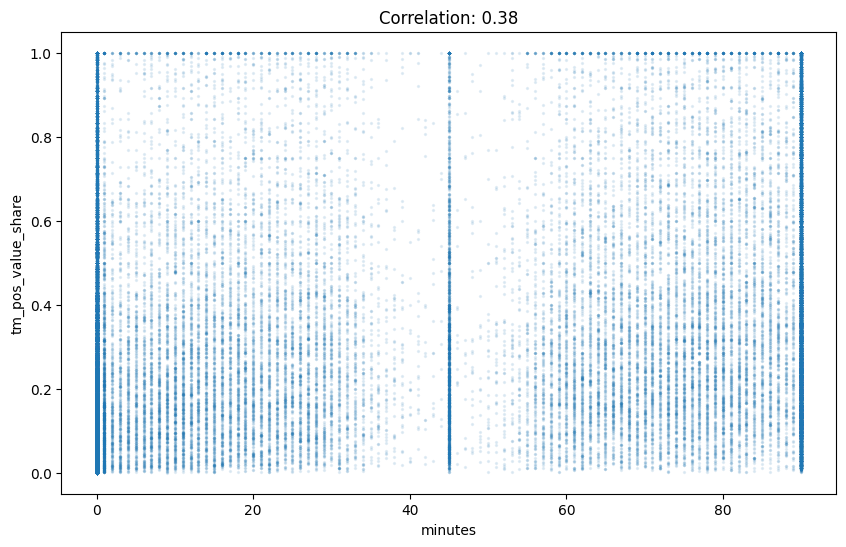

In [25]:
# not a huge correlation
paired = training_data.drop_nulls(["minutes", "tm_pos_value_share"]).filter(
    pl.col("tm_pos_value_share").is_not_nan()
)
corr = np.corrcoef(paired["minutes"], paired["tm_pos_value_share"])[0, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(paired["minutes"], paired["tm_pos_value_share"], s=2, alpha=0.1)
ax.set_xlabel("minutes")
ax.set_ylabel("tm_pos_value_share")
ax.set_title(f"Correlation: {corr:.2f}")
plt.show()



# Experiment: do the transfermarkt features help?

Trains on `TRAINING_SEASONS` and scores the held-out seasons, for the production
feature set and for the candidate set, and logs both to MLflow under the usual
`minutes_played_classification` experiment. Nothing here registers a model or touches the production alias.


In [26]:
import mlflow
import mlflow.sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from fantasy_football.constants import MINUTES_EXPERIMENT, MLFLOW_TRACKING_URI
from fantasy_football.modelling.minutes import (
    BOOL_FEATURES as PROD_BOOL_FEATURES,
    CAT_FEATURES as PROD_CAT_FEATURES,
    MINUTES_BUCKETS,
    NUM_FEATURES as PROD_NUM_FEATURES,
    boundary_metrics,
)

# custom feature lists
CANDIDATE_NUM_FEATURES = [
    "players_same_pos",
    "chance_of_playing_this_round",
    "fit_rivals_same_pos",
    "fit_rivals_ahead",
    "avg_minutes_rolling_5",
    "games_played_this_season",
    "prev_season_minutes",
    "prev_season_start_rate",
    "pl_seasons_played",
    "seasons_since_last_pl",
    "age_years",
    "value_tm",
    "players_same_tm_pos",
    "tm_pos_value_share",
    "tm_pos_value_rank_norm",
    "prev_game_minutes",
    "prev_game_minutes_2",
    "days_since_prev_game",
    "prev_pct_position_minutes",
    "minutes_to_date",
    "pct_position_minutes_to_date",
    "rivals_joined_same_pos",
    "higher_value_rivals_joined_same_pos",
    "max_rival_value_eur",
    "days_since_rival_joined",
]
CANDIDATE_CAT_FEATURES = [
    "is_pl_newcomer",
    "is_promoted_club",
    "tm_position",
]

In [ ]:
def make_experiment_pipeline(num_features: list[str], cat_features: list[str]) -> Pipeline:
    """Same shape as minutes.make_pipeline, over an arbitrary feature list."""
    preprocessor = ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                num_features,
            ),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )
    return Pipeline(
        [
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=1000)),
        ]
    )

In [35]:
def prepare(frame: pl.DataFrame, num_features: list[str], cat_features: list[str]) -> pl.DataFrame:
    """Cast the categoricals to string so the one-hot encoder accepts nulls."""
    return frame.with_columns(
        [pl.col(column).cast(pl.Utf8).fill_null("unknown") for column in cat_features]
    ).select(num_features + cat_features).to_pandas()


In [29]:
def run_experiment(run_name: str, num_features: list[str], cat_features: list[str], description: str) -> dict[str, float]:
    """Fit on training_data, score test_data, log the run to MLflow."""
    missing = [c for c in num_features + cat_features if c not in training_data.columns]
    if missing:
        raise ValueError(f"features not in training_data: {missing}")

    model = make_experiment_pipeline(num_features, cat_features)
    model.fit(
        prepare(training_data, num_features, cat_features),
        training_data["minutes_bucket"].to_list(),
    )
    test_features = prepare(test_data, num_features, cat_features)
    actual_bucket = test_data["minutes_bucket"].to_list()
    proba = model.predict_proba(test_features)
    metrics = boundary_metrics(
        actual_bucket,
        proba,
        list(model.classes_),
        test_data["minutes"].to_list(),
    )

    # Per class in the artifact, overall in the metrics. labels= keeps the
    # key order stable so two runs' artifacts diff cleanly.
    report = classification_report(
        actual_bucket,
        model.predict(test_features),
        labels=MINUTES_BUCKETS,
        output_dict=True,
        zero_division=0,
    )
    headline = {
        "accuracy": report["accuracy"],
        **{
            f"{average}_{metric}": report[f"{average} avg"][metric]
            for average in ("macro", "weighted")
            for metric in ("precision", "recall", "f1-score")
        },
    }

    with mlflow.start_run(run_name=run_name, description=description):
        mlflow.log_params(
            {
                "n_num_features": len(num_features),
                "n_cat_features": len(cat_features),
                "train_seasons": ",".join(TRAINING_SEASONS),
                "train_rows": training_data.height,
                "test_rows": test_data.height,
            }
        )
        mlflow.log_dict(
            {"num": num_features, "cat": cat_features}, "features.json"
        )
        mlflow.log_metrics(metrics | headline)
        mlflow.log_dict(report, "classification_report.json")
        mlflow.sklearn.log_model(model, name="model")

    return metrics | headline

In [31]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MINUTES_EXPERIMENT)

scores = {
    "production": run_experiment(
        "production_features",
        PROD_NUM_FEATURES,
        PROD_CAT_FEATURES + PROD_BOOL_FEATURES,
        "baseline run on production feature with new metrics"
    ),
    "candidate": run_experiment(
        "candidate_features", CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES, "new feature"
    ),
}

comparison = pl.DataFrame(
    [
        {"metric": metric, "production": scores["production"][metric], "candidate": value}
        for metric, value in scores["candidate"].items()
        if metric in scores["production"]
    ]
).with_columns((pl.col("candidate") - pl.col("production")).alias("delta"))

comparison

/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/jamie/personal/fant

metric,production,candidate,delta
str,f64,f64,f64
"""logloss_appear""",0.288728,0.268432,-0.020296
"""brier_appear""",0.088738,0.081044,-0.007694
"""logloss_60""",0.28303,0.254779,-0.028251
"""brier_60""",0.090187,0.079087,-0.0111
"""auc_appear""",0.94835,0.955617,0.007267
…,…,…,…
"""macro_recall""",0.626665,0.665317,0.038653
"""macro_f1-score""",0.620876,0.668463,0.047586
"""weighted_precision""",0.766375,0.795182,0.028807


# Different Architectures

Testing out different model architectures, and their impact on the score. For now, likely to be:
- RandomForest
- XGBoost

In [42]:
# build a new pipeline for non LogisticRegression models
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CANDIDATE_CAT_FEATURES
        ),
         ("num", "passthrough", CANDIDATE_NUM_FEATURES)
    
    ]
)
rf_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("clf", RandomForestClassifier())
    ]
)


rf_model = rf_pipeline.fit(
    prepare(training_data, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES),
    training_data["minutes_bucket"].to_list()
)
test_features = prepare(test_data, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES)
actual_bucket = test_data["minutes_bucket"].to_list()
proba = rf_model.predict_proba(test_features)
metrics = boundary_metrics(
    actual_bucket,
    proba,
    list(rf_model.classes_),
    test_data["minutes"].to_list(),
)

report = classification_report(
    actual_bucket,
    rf_model.predict(test_features),
    labels=MINUTES_BUCKETS,
    output_dict=True,
    zero_division=0,
)

headline = {
    "accuracy": report["accuracy"],
    **{
        f"{average}_{metric}": report[f"{average} avg"][metric]
        for average in ("macro", "weighted")
        for metric in ("precision", "recall", "f1-score")
        
    }
}

with mlflow.start_run(run_name="RandomForest Model", description="Testing out a RandomForest with the new feature set"):
    mlflow.log_params(
        {
            "n_num_features": len(CANDIDATE_NUM_FEATURES),
            "n_cat_features": len(CANDIDATE_CAT_FEATURES),
            "train_seasons": ",".join(TRAINING_SEASONS),
            "train_rows": training_data.height,
            "test_rows": test_data.height,
        }
    )
    mlflow.log_dict(
        {"num": CANDIDATE_NUM_FEATURES, "cat": CANDIDATE_CAT_FEATURES}, "features.json"
    )
    mlflow.log_metrics(metrics | headline)
    mlflow.log_dict(report, "classification_report.json")
    mlflow.sklearn.log_model(rf_model, name="model")

2026/09/07 17:46:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/07 17:46:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [49]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CANDIDATE_CAT_FEATURES
        ),
        ("num", "passthrough", CANDIDATE_NUM_FEATURES)
    ]
)
xgb_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("clf", XGBClassifier())
    ]
)

le = LabelEncoder()
labels = le.fit(training_data["minutes_bucket"].to_list()).classes_

xgb_model = xgb_pipeline.fit(
    prepare(training_data, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES),
    le.fit_transform(training_data["minutes_bucket"].to_list()),
)
test_features = prepare(test_data, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES)
actual_bucket = test_data["minutes_bucket"].to_list()
proba = xgb_model.predict_proba(test_features)
metrics = boundary_metrics(
    actual_bucket,
    proba,
    le.classes_,
    test_data["minutes"].to_list(),
)

report = classification_report(
    actual_bucket,
    le.inverse_transform(xgb_model.predict(test_features)),
    labels=MINUTES_BUCKETS,
    output_dict=True,
    zero_division=0,
)

headline = {
    "accuracy": report["accuracy"],
    **{
        f"{average}_{metric}": report[f"{average} avg"][metric]
        for average in ("macro", "weighted")
        for metric in ("precision", "recall", "f1-score")
        
    }
}

with mlflow.start_run(run_name="XGBoost Model", description="Testing out a XGBoost with the new feature set"):
    mlflow.log_params(
        {
            "n_num_features": len(CANDIDATE_NUM_FEATURES),
            "n_cat_features": len(CANDIDATE_CAT_FEATURES),
            "train_seasons": ",".join(TRAINING_SEASONS),
            "train_rows": training_data.height,
            "test_rows": test_data.height,
        }
    )
    mlflow.log_dict(
        {"num": CANDIDATE_NUM_FEATURES, "cat": CANDIDATE_CAT_FEATURES}, "features.json"
    )
    mlflow.log_metrics(metrics | headline)
    mlflow.log_dict(report, "classification_report.json")
    mlflow.sklearn.log_model(xgb_model, name="model")

2026/09/07 17:57:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/07 17:57:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


# Inspecting known error with best model

The error that made me look into the minutes model was that Nick Pope was consistently being expected to be Newcastle's number 1, even though a replacement [has been signed](https://www.bbc.co.uk/sport/football/articles/ckg9d1ymrvlo). I'm just going to check the predictions to see what it had for this.

In [53]:
# Seeing what's going on with Nick pope
TARGET_SEASON = "2026-27"
TARGET_GWS = [1, 2]
PLAYER_PATTERN = "(?i)pope"

xgb_model.fit(
    prepare(training_data, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES),
    le.fit_transform(training_data["minutes_bucket"].to_list()),
)

player_rows = test_data.filter(
    pl.col("name").str.contains(PLAYER_PATTERN)
    & (pl.col("season") == TARGET_SEASON)
    & pl.col("gw").is_in(TARGET_GWS)
).sort("gw", "opponent")

print(f"{player_rows.height} rows for {player_rows['name'].unique().to_list()}")

player_features = prepare(player_rows, CANDIDATE_NUM_FEATURES, CANDIDATE_CAT_FEATURES)
proba = xgb_model.predict_proba(player_features)

predictions = (
    player_rows.select("season", "gw", "element", "name", "team", "opponent", "minutes", "minutes_bucket")
    .with_columns(pl.Series("predicted_bucket", le.inverse_transform(xgb_model.predict(player_features))))
    .with_columns([pl.Series(f"p_{cls}", proba[:, i]) for i, cls in enumerate(xgb_model.classes_)])
)
predictions


2 rows for ['Nick Pope']


season,gw,element,name,team,opponent,minutes,minutes_bucket,predicted_bucket,p_0,p_1,p_2
str,i64,i64,str,str,i64,i64,str,str,f32,f32,f32
"""2026-27""",1,442,"""Nick Pope""","""Newcastle""",14,0,"""0_minutes""","""60_minutes_plus""",0.144238,0.001269,0.854493
"""2026-27""",2,442,"""Nick Pope""","""Newcastle""",19,0,"""0_minutes""","""0_minutes""",0.704309,0.00804,0.287651


In [33]:
# The feature values behind those predictions
player_rows.select(["gw", "opponent"] + CANDIDATE_NUM_FEATURES + CANDIDATE_CAT_FEATURES).transpose(
    include_header=True,
    header_name="feature",
    column_names=[f"gw{gw}_v_{opp}" for gw, opp in zip(player_rows["gw"], player_rows["opponent"])],
)


feature,gw1_v_14,gw2_v_19
str,str,str
"""gw""","""1""","""2"""
"""opponent""","""14""","""19"""
"""players_same_pos""","""4""","""4"""
"""chance_of_playing_this_round""","""100""","""100"""
"""fit_rivals_same_pos""","""3""","""3"""
…,…,…
"""max_rival_value_eur""","""18000000""","""18000000"""
"""days_since_rival_joined""","""20""","""26"""
"""is_pl_newcomer""","""0""","""0"""
